In [1]:
# ! pip install geojson
# ! pip install gurobipy
# ! -m pip list | grep gurobipy
# ! conda install -c conda-forge pyscipopt
# ! conda update -n base -c defaults conda
import geojson
from util import *
from shapely import Polygon
# from utils import *

In [2]:
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/netherlands/states.geojson"
path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/germany/states.geojson"
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/germany/counties.geojson"
# # path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/usa/states.geojson"
# # path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/france/states.geojson"
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/world/world.geojson"


In [3]:
gj = parse_geojson(path_to_file)
# for i in range(len(gj['features'])):
    # print(gj['features'][i])
    # print(gj['features'][i]['properties']['name'])

In [4]:
def get_all_points(path_to_file, verbose=False):
    gj = parse_geojson(path_to_file)
    points = {}
    for i in range(len(gj['features'])):
        if verbose:
            print(gj['features'][i])
            print(gj['features'][i]['properties']['name'])
        points[gj['features'][i]['properties']['name']] = gj['features'][i]['geometry']['coordinates'][0]
    return points

In [5]:
print(get_all_points(path_to_file, verbose=False))

{'Sachsen': [[12.101344, 50.31398], [12.100998, 50.314371], [12.093712, 50.322613], [12.06529, 50.32791], [12.051957, 50.326903], [12.047616, 50.327006], [12.043431, 50.327755], [12.039865, 50.32884], [11.998886, 50.346436], [11.989429, 50.349175], [11.986018, 50.351552], [11.981832, 50.371189], [11.982297, 50.375427], [11.983383, 50.378631], [11.984778, 50.380749], [11.981212, 50.385323], [11.960232, 50.394159], [11.949845, 50.405218], [11.947829, 50.406743], [11.945659, 50.408551], [11.943798, 50.410515], [11.940543, 50.414546], [11.931706, 50.416923], [11.9053, 50.415166], [11.897393, 50.423408], [11.897393, 50.426276], [11.899718, 50.429325], [11.906075, 50.433227], [11.910622, 50.435371], [11.914963, 50.436948], [11.931086, 50.440332], [11.934342, 50.442089], [11.935892, 50.444932], [11.936047, 50.449867], [11.937132, 50.4532], [11.945194, 50.458316], [11.947519, 50.462243], [11.947054, 50.471028], [11.945194, 50.475162], [11.942403, 50.47834], [11.930156, 50.484206], [11.92752, 5

In [6]:
# for region in get_all_points(path_to_file, verbose=False):
#     points = get_all_points(path_to_file, verbose=False)[region]
#     print(len(points))
#     rdp_points = rdp_target(points, 100)

#     #Example: Region of Netherlands
#     square = rdp_points
#     if isinstance(square, list):
#         square = np.array(square)
#     plot_poly(square, title="Original Polygon")
#     polygon = Polygon(square)
#     print("Original area: ", polygon.area)
#     target = 10.0
#     for name, func in [("Radial QP", PolyAreaRadialQP)]:
                    
#         try:
#             new_pts, area = func(square, target)
#             polygon = Polygon(new_pts)

#             print(f"{name}: area = {area:.6f}, max displacement = {np.max(np.abs(np.array(new_pts)-np.array(square))):.4f}")
#             print("area: ", polygon.area)
#             centroid = np.mean(new_pts, axis=0)
#             compare_polys(square, new_pts, title=f"{region}", centroid=centroid)
#         except Exception as e:
#             print(f"{name}: failed - {e}")  

In [7]:
polygon = []
target_areas = [] # [0.2, 0.2, 0.3, 0.2, 0.1, 0.4, 0.3, 0.2, 0.1, 0.2, 0.3, 0.4]
for points in get_all_points(path_to_file, verbose=False).values():
    target_areas.append(Polygon(points).area)
target_positions = []
names = []
centroid = []
for name, points in get_all_points(path_to_file, verbose=False).items():
    names.append(name)
    print(f"{name} area: {Polygon(points).area}")
    rdp_points = points # rdp_target(points, 100)
    polygon.append(rdp_points)
    target_positions.append(np.mean(rdp_points, axis=0) + [10, 10])
    centroid.append((10.187972, 51.314139))
    # names.append(name)
    # print(np.mean(rdp_points, axis=0))
    # 51° 18' 50,9"N 10° 11' 16,7"E

Sachsen area: 2.3287033050724992
Bayern area: 8.596117972568507
Rheinland-Pfalz area: 2.5153278922075
Saarland area: 0.3286312192074997
Schleswig-Holstein area: 2.0609734473879997
Niedersachsen area: 6.3627897060705045
Nordrhein-Westfalen area: 4.468057750550998
Baden-Württemberg area: 4.399586496972497
Brandenburg area: 4.090010273537499
Mecklenburg-Vorpommern area: 2.9690162417609955
Bremen area: 0.008831973080999875
Hamburg area: 0.10486796472600042
Hessen area: 2.668163793554997
Thüringen area: 2.053022958667003
Sachsen-Anhalt area: 2.704463506926498
Berlin area: 0.11767556416649891


In [8]:
print(names)

['Sachsen', 'Bayern', 'Rheinland-Pfalz', 'Saarland', 'Schleswig-Holstein', 'Niedersachsen', 'Nordrhein-Westfalen', 'Baden-Württemberg', 'Brandenburg', 'Mecklenburg-Vorpommern', 'Bremen', 'Hamburg', 'Hessen', 'Thüringen', 'Sachsen-Anhalt', 'Berlin']


In [9]:
# new_polys, areas = PolyAreaRadialLP_batch_position(polygon, target_areas, target_positions)
# plot_polys(new_polys, title="Optimized Polygons")

In [10]:
# new_polys, areas = PolyAreaRadialQP_batch_nooverlap_variante(polygon, target_areas, target_positions, w_pos=10, dmin=10,verbose=True) # PolyAreaRadialQP_batch(polygon, targets_areas)
# plot_polys(new_polys, title="Optimized Polygons")
# print(target_positions)

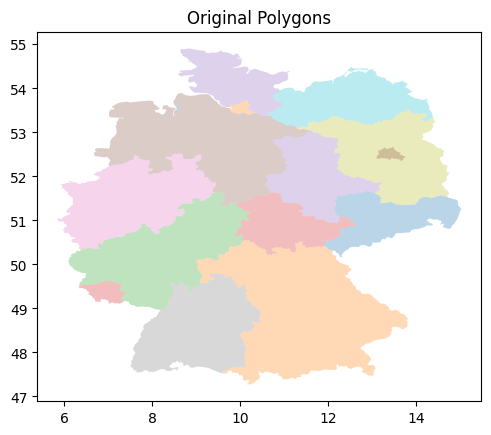

In [11]:
plot_polys(polygon, title="Original Polygons", legend=False)

In [ ]:
polygons = polygon
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical(polygons)
# print(polygons[0])
new_polys, areas, problem_status, problem_value = CartogramFramework_global(
    polygons=polygons, 
    target_areas= 10, 
    fixed_points=None, 
    shape="square", 
    target_centers=target_positions,
    horizontal_pairs=horizontal_pairs,
    vertical_pairs=vertical_pairs,
    neighboring_pairs=neighbouring_pairs(polygons),
    shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),
    cartographic_error=1.0,
    shape_deformation=1.0,
    topological_accuracy=0.0,
    spatial_deformation=1.0,
    local_shape=1.0,)
plot_polys(new_polys, title="Optimized Polygons", centroids=True, legend=False, target_centers=target_positions)
print(areas)

infeasible


TypeError: 'NoneType' object is not iterable

In [ ]:
sum = 0
for poly in new_polys:
    sum += Polygon(poly).area
    print(Polygon(poly).area)
print("Total area: ", sum)
print("Average area: ", sum/len(new_polys))

10.00000000000727
10.000000000003633
10.00000000000727
10.000000000003633
10.000000000000014
10.000000000003633
10.000000000000014
10.000000000000014
10.00000000000727
10.000000000000014
10.000000000000014
9.999999999996394
10.000000000003633
9.999999999996394
10.000000000000014
10.000000000000014
Total area:  160.00000000002922
Average area:  10.000000000001826


In [ ]:
for poly, i in zip(polygons, range(len(polygons))):
    print(f"Polygon {names[i]} bounds: {polygon_bounds(poly)}")

Polygon Sachsen bounds: {'south': 50.160815, 'east': 15.022059, 'north': 51.670076, 'west': 11.897393}
Polygon Bayern bounds: {'south': 47.271121, 'east': 13.816862, 'north': 50.562857, 'west': 8.976589}
Polygon Rheinland-Pfalz bounds: {'south': 48.95825, 'east': 8.504577, 'north': 50.932705, 'west': 6.096403}
Polygon Saarland bounds: {'south': 49.105014, 'east': 7.390588, 'north': 49.629477, 'west': 6.342279}
Polygon Schleswig-Holstein bounds: {'south': 53.363875, 'east': 11.135509, 'north': 54.9059, 'west': 8.599864}
Polygon Niedersachsen bounds: {'south': 51.290461, 'east': 11.58134, 'north': 53.892483, 'west': 6.671716}
Polygon Nordrhein-Westfalen bounds: {'south': 50.32308, 'east': 9.462141, 'north': 52.524185, 'west': 5.85249}
Polygon Baden-Württemberg bounds: {'south': 47.532743, 'east': 10.495101, 'north': 49.795591, 'west': 7.511872}
Polygon Brandenburg bounds: {'south': 51.347977, 'east': 14.761403, 'north': 53.543811, 'west': 11.27409}
Polygon Mecklenburg-Vorpommern bounds: 

In [ ]:
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical(polygons)
h_pair = []
for pair in horizontal_pairs:
    h_pair.append((names[pair[0]], names[pair[1]]))
print("Horizontal pairs: ", h_pair)
print("Horizontal pairs: ", horizontal_pairs)
v_pair = []
for pair in vertical_pairs:
    v_pair.append((names[pair[0]], names[pair[1]]))
print("Vertical pairs: ", v_pair)
print("Vertical pairs: ", vertical_pairs)

Horizontal pairs:  [('Sachsen', 'Rheinland-Pfalz'), ('Sachsen', 'Saarland'), ('Sachsen', 'Schleswig-Holstein'), ('Sachsen', 'Niedersachsen'), ('Sachsen', 'Nordrhein-Westfalen'), ('Sachsen', 'Baden-Württemberg'), ('Sachsen', 'Bremen'), ('Sachsen', 'Hamburg'), ('Sachsen', 'Hessen'), ('Bayern', 'Rheinland-Pfalz'), ('Bayern', 'Saarland'), ('Bayern', 'Bremen'), ('Rheinland-Pfalz', 'Sachsen'), ('Rheinland-Pfalz', 'Bayern'), ('Rheinland-Pfalz', 'Schleswig-Holstein'), ('Rheinland-Pfalz', 'Brandenburg'), ('Rheinland-Pfalz', 'Mecklenburg-Vorpommern'), ('Rheinland-Pfalz', 'Bremen'), ('Rheinland-Pfalz', 'Hamburg'), ('Rheinland-Pfalz', 'Thüringen'), ('Rheinland-Pfalz', 'Sachsen-Anhalt'), ('Rheinland-Pfalz', 'Berlin'), ('Saarland', 'Sachsen'), ('Saarland', 'Bayern'), ('Saarland', 'Schleswig-Holstein'), ('Saarland', 'Baden-Württemberg'), ('Saarland', 'Brandenburg'), ('Saarland', 'Mecklenburg-Vorpommern'), ('Saarland', 'Bremen'), ('Saarland', 'Hamburg'), ('Saarland', 'Hessen'), ('Saarland', 'Thüringen

In [ ]:
neighbouring_pairs = neighbouring_pairs(polygons)
n_pair = []
for pair in neighbouring_pairs:
    n_pair.append((names[pair[0]], names[pair[1]]))
print("Neighbouring pairs: ", n_pair)

Neighbouring pairs:  [('Sachsen', 'Bayern'), ('Sachsen', 'Brandenburg'), ('Sachsen', 'Thüringen'), ('Sachsen', 'Sachsen-Anhalt'), ('Bayern', 'Baden-Württemberg'), ('Bayern', 'Hessen'), ('Bayern', 'Thüringen'), ('Rheinland-Pfalz', 'Saarland'), ('Rheinland-Pfalz', 'Nordrhein-Westfalen'), ('Rheinland-Pfalz', 'Baden-Württemberg'), ('Rheinland-Pfalz', 'Hessen'), ('Schleswig-Holstein', 'Niedersachsen'), ('Schleswig-Holstein', 'Mecklenburg-Vorpommern'), ('Schleswig-Holstein', 'Hamburg'), ('Niedersachsen', 'Nordrhein-Westfalen'), ('Niedersachsen', 'Brandenburg'), ('Niedersachsen', 'Mecklenburg-Vorpommern'), ('Niedersachsen', 'Bremen'), ('Niedersachsen', 'Hamburg'), ('Niedersachsen', 'Hessen'), ('Niedersachsen', 'Thüringen'), ('Niedersachsen', 'Sachsen-Anhalt'), ('Nordrhein-Westfalen', 'Hessen'), ('Baden-Württemberg', 'Hessen'), ('Brandenburg', 'Mecklenburg-Vorpommern'), ('Brandenburg', 'Sachsen-Anhalt'), ('Hessen', 'Thüringen'), ('Thüringen', 'Sachsen-Anhalt')]


In [ ]:
shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons)
shared_verticies_named = []
for item in shared_vertices_of_neighbors:
    i, j, shared_points = item
    shared_verticies_named.append((names[i], names[j], shared_points))
print("Shared vertices of neighbors: ", shared_verticies_named)

Shared vertices of neighbors:  [('Sachsen', 'Bayern', [[11.9053, 50.415166], [11.931706, 50.416923], [11.940543, 50.414546], [11.943798, 50.410515], [11.945659, 50.408551], [11.947829, 50.406743], [11.949845, 50.405218], [11.960232, 50.394159], [11.981212, 50.385323], [11.984778, 50.380749], [11.983383, 50.378631], [11.982297, 50.375427], [11.981832, 50.371189], [11.986018, 50.351552], [11.989429, 50.349175], [11.998886, 50.346436], [12.039865, 50.32884], [12.043431, 50.327755], [12.047616, 50.327006], [12.051957, 50.326903], [12.06529, 50.32791], [12.093712, 50.322613], [12.100998, 50.314371], [12.101344, 50.31398]]), ('Sachsen', 'Brandenburg', [[14.70677, 51.540828], [14.706576, 51.540834], [14.663374, 51.542074], [14.620379, 51.553262], [14.595368, 51.562486], [14.573509, 51.56507], [14.55258, 51.564501], [14.509275, 51.556853], [14.377242, 51.515512], [14.338588, 51.509931], [14.30474, 51.524091], [14.268928, 51.532359], [14.220972, 51.536286], [14.158754, 51.526881], [14.118549, 5

In [ ]:
# polygons = polygon
# new_polys, areas = PolyAreaRadialLP_all(polygons, 1, None, shape="circle", cartographic_error=1)
# plot_polys(new_polys, title="Optimized Polygons")
# print(areas)

In [ ]:
# new_polys, areas = PolyAreaRadialQP_batch_SAT_MICP(polygon, target_areas, target_positions, w_pos=10) # PolyAreaRadialQP_batch(polygon, targets_areas)
# plot_polys(new_polys, title="Optimized Polygons")

In [ ]:
# new_polys, areas = PolyAreaRadialQP_batch_nooverlap(polygon, target_areas, target_positions, w_pos=10, dmin=10,verbose=True) # PolyAreaRadialQP_batch(polygon, targets_areas)
# plot_polys(new_polys, title="Optimized Polygons")

## Show for all regions of the Netheerlands

In [ ]:
# for region in get_all_points(path_to_file, verbose=False):
#     points = get_all_points(path_to_file, verbose=False)[region]
#     # print(len(points))
#     rdp_points = points # rdp_target(points, 100)
    
#     #Example: Region of Netherlands
#     square = rdp_points
#     if isinstance(square, list):
#         square = np.array(square)
#     plot_poly(square, title=f"Original Polygon: {region}")
#     polygon = Polygon(square)
#     print("Original area: ", polygon.area)
#     target = 10.0
#     print("---------------------------------------------------------------------------")
#     for name, func in [("Radial QP", PolyAreaRadialQP), ("LP", PolyAreaRadialLP)]: #, ("Circle", PolyAreaRadialLP_Circle)]:
                    
#         try:
#             new_pts, area = func(square, target)
#             polygon = Polygon(new_pts)
#             print(f"{name}: area = {area:.6f}, max displacement = {np.max(np.abs(np.array(new_pts)-np.array(square))):.4f}")
#             print("area: ", polygon.area)
#             print("Number of points: ", len(new_pts))
#             # plot_poly(new_pts, title=f"{name} Polygon")
#             compare_polys(square, new_pts, title=f"{name} Comparison {region}", centroid=np.mean(new_pts, axis=0))
#         except Exception as e:
#             print(f"{name}: failed - {e}")  

In [ ]:
# features = gj['features'][8]

In [ ]:
# points = features['geometry']['coordinates'][0] 

In [ ]:
# print(len(points))
# rdp_points = rdp_target(points, 100)
# # print(len(rdp_points))
# # plot_poly(rdp_points)
# # visvalingam_points = visvalingam(points, 20)
# # print(len(visvalingam_points))
# # plot_poly(visvalingam_points)
# # imai_iri_points = imai_iri(points, 0.0001)
# # print(len(imai_iri_points))
# # plot_poly(imai_iri_points)

In [ ]:
# import math

# def annular_segment(center=(0, 0), r_inner=1.0, r_outer=2.0,
#                    start_angle=0, end_angle=300, n_points=100):
#     """
#     Creates a polygon made of two arcs (inner and outer) sharing the same center.
    
#     Angles in degrees.
#     """
#     cx, cy = center
#     points = []

#     # Outer arc (start -> end)
#     for i in range(n_points + 1):
#         t = start_angle + (end_angle - start_angle) * i / n_points
#         rad = math.radians(t)
#         x = cx + r_outer * math.cos(rad)
#         y = cy + r_outer * math.sin(rad)
#         points.append([x, y])

#     # Inner arc (end -> start, reversed)
#     for i in range(n_points + 1):
#         t = end_angle - (end_angle - start_angle) * i / n_points
#         rad = math.radians(t)
#         x = cx + r_inner * math.cos(rad)
#         y = cy + r_inner * math.sin(rad)
#         points.append([x, y])

#     return points


# # Example usage
# polygon = annular_segment(center=(0, 0), r_inner=0.1, r_outer=0.2,
#                           start_angle=0, end_angle=300, n_points=50)

# print(polygon)

In [ ]:
# plot_poly(polygon, title="Annular Segment")

In [ ]:
# # Example: unit square (area 1)
# # square = [[0,0], [1,0], [1,1], [0,1]]
# square = polygon
# #Example: Region of Netherlands
# # square = rdp_points
# if isinstance(square, list):
#     square = np.array(square)
# plot_poly(square, title="Original Polygon")
# polygon = Polygon(square)
# print("Original area: ", polygon.area)
# target = 10.0
# print("---------------------------------------------------------------------------")
# for name, func in [
#                 # ("Radial QP", PolyAreaRadialQP), 
#                 ("LP", PolyAreaRadialLP),

#                 # ("ConvexOptimization", maxPolyAreaConvexOptim),
#                 # ("ConvexOptimization2", maxPolyAreaConvexOptim2),
#                 # # ("ConvexRelaxation", maxPolyAreaConvexRelax), 
#                 # ("ConvexRelaxation2", maxPolyAreaConvexRelax2), 
#                 # ("GeometricOptimization", maxPolyAreaGeometricOptim),    

#                 # ("QP", PolyAreaQP),   
#                 # ("QP2", PolyAreaQP2), 

#                 # ("Penalty", PolyAreaPenalty),    
#                 # ("Penalty2", PolyAreaPenalty2), 

#                 # ("MinSurface", PolyAreaMinimalSurface), 
#                 # ("MinSurface2", PolyAreaMinimalSurface2),   

#                 # ("LP2", PolyAreaLP2),   

#                 # ("EdgeDir", PolyAreaEdgeDirections), 
#                 # ("EdgeDir2", PolyAreaEdgeDirections2),
                 
#                 # ("Edge LP", PolyAreaEdgeLP),
#                 # ("MVEE", PolyAreaMVEE),
#                 # ("Radial MVEE", PolyAreaRadialMVEE), 
#                 # ("BBox", PolyAreaBBox),
#                 # ("Radial LP", PolyAreaRadialLP),
#                 # ("Perimeter", PolyAreaPerimeter),
#                 # ("Vertex Box", PolyAreaVertexBox), 

#                 # ("UniformScale", PolyAreaUniformScale),
#                 # ("UniformScale2", PolyAreaUniformScale2),
#                 # ("LP", PolyAreaLP),
#                 # ("RadialOptim", PolyAreaRadialOptim), 
#                 # ("Sequential", PolyAreaSequential), 
#                 # ("MVEE Fixed", PolyAreaMVEE_fixed), 
#                 # ("Hull Deform", PolyAreaHullDeform),
#                 # ("Radial Scaling", PolyAreaRadialScaling),
#                 # ("Covariance", PolyAreaCovariance), 
#                 # ("Hull Scale", PolyAreaHullScale),
#                 ]:
#     try:
#         new_pts, area = func(square, target)
#         polygon = Polygon(new_pts)
#         print(f"{name}: area = {area:.6f}, max displacement = {np.max(np.abs(np.array(new_pts)-np.array(square))):.4f}")
#         print("area: ", polygon.area)
#         # plot_poly(new_pts, title=f"{name} Polygon")
#         compare_polys(square, new_pts, title=f"{name} Comparison", centroid=np.mean(new_pts, axis=0), support_lines=True)
#     except Exception as e:
#         print(f"{name}: failed - {e}")

In [ ]:
# # points = np.array(features['geometry']['coordinates'][0])
# # print(points)
# target_area = 10
# if isinstance(rdp_points, list):
#     rdp_points = np.array(rdp_points)

# z_optGO, area_optGO = maxPolyAreaGeometricOptim(rdp_points, target_area)
# z_optCR, area_optCR = maxPolyAreaConvexRelax(rdp_points, target_area)
# z_optCO, area_optCO = maxPolyAreaConvexOptim(rdp_points, target_area)
# z_optCO2, area_optCO2 = maxPolyAreaConvexOptim2(rdp_points, target_area)
# # z_optCR2, area_optCR2 = maxPolyAreaConvexRelax2(rdp_points, target_area)


# plot_poly(z_optGO)
# print("Area:", area_optGO)
# plot_poly(z_optCR)
# print("Area:", area_optCR)
# plot_poly(z_optCO)
# print("Area:", area_optCO)
# plot_poly(z_optCO2)
# print("Area:", area_optCO2)
# # plot_poly(z_optCR2)
# # print("Area:", area_optCR2)


# print("Orginal Points", rdp_points)
# print("Convex Relaxation", z_optCR)
# polygon = Polygon(rdp_points)
# GOpolygon = Polygon(z_optGO)
# CRpolygon = Polygon(z_optCR)
# COpolygon = Polygon(z_optCO)
# CO2polygon = Polygon(z_optCO2)
# # CR2polygon = Polygon(z_optCR2)
# print("Original Points Area:", polygon.area)
# print("Geometric Optimization Area:", GOpolygon.area)
# print("Convex Relaxation Area:", CRpolygon.area)
# print("Convex Optimization Area:", COpolygon.area)
# print("Convex Optimization 2 Area:", CO2polygon.area)
# #   
# # print("Convex Relaxation 2 Area:", CR2polygon.area)


